# Direct PSD Multi-Component Stress Expansion

Full-field stress PSD under base excitation &mdash; **no accelerometer required**.

> ### FOR THE WRITING AGENT
>
> This notebook implements the **direct PSD expansion** method &mdash; a companion/comparison
> to the transmissibility expansion notebook. Both use the same Stage 1 mode shapes and
> the same camera recording (`40Hz-300Hz_0,02-0,03g`).
>
> **What makes this method different:**
> - Uses **camera data only** (no accelerometer needed for Stage 2)
> - Virtual-reference denoising removes camera noise via inter-pixel cross-spectra
> - NNLS decomposition on the **denoised** PSD preserves spatial mode shapes
> - The expanded PSD matches the denoised camera PSD (noise-free)
>
> **All sections are article-ready.** The pipeline is:
> 1. Stage 1 mode shapes (shared with transmissibility notebook)
> 2. Camera Welch PSD (raw, includes noise)
> 3. Virtual reference denoising &rarr; noise-free PSD
> 4. NNLS modal decomposition on denoised PSD
> 5. Multi-component expansion via mode shapes
>
> **Key comparison point for the article:**
> Both methods produce noise-free structural stress PSDs.
> The transmissibility method additionally separates the structural transfer function
> from the excitation (reusable for different $S_{aa}$), while this method is simpler
> (no accelerometer) but excitation-specific.

---

1. **Stage 1**: Extract stress mode shapes from SEMM FRFs (all 4 components)
2. **Stage 2**: Compute camera stress PSD directly via Welch
3. **Denoise**: Virtual reference denoising &mdash; use inter-pixel cross-spectra to remove camera noise
4. **Decompose**: Fit modal contributions via NNLS: $S_\text{clean}(f,x) \approx \sum_r \beta_r(f)\,|\psi_{r,\text{cam}}(x)|^2$
5. **Expand**: Swap in mode shapes for other components: $S_c(f,x) = \sum_r \beta_r(f)\,|\psi_{r,c}(x)|^2$

The camera time history already contains the full stress response including
the effect of the excitation. Stage 1 provides the relationship between
stress components via mode shapes.

---

### Key properties of this method

**No accelerometer needed** &mdash; uses only camera data for Stage 2.

**Virtual reference denoising (key innovation):**
The camera's spatial redundancy ($N = 930$ pixels) enables noise removal without
an external reference. A virtual reference $r(t) = \text{mean of all pixels}$ has
$\sqrt{N} \approx 30\times$ noise reduction. Cross-correlating each pixel with this
reference removes the remaining pixel noise:
$$S_\text{clean}(f,x) = |G_{xr}|^2 / G_{rr} \approx |H|^2 S_{aa}$$
This achieves the same denoising as the transmissibility method's H1 estimator,
but using the camera itself as the reference.

**Cannot separate structure from excitation:**
Unlike the transmissibility method, this approach produces the stress PSD
for one specific excitation profile. If the excitation changes, the camera
measurement must be repeated.

**Comparison with transmissibility expansion:**

| | Direct PSD + virtual ref | Transmissibility |
|---|---|---|
| **Accelerometer** | Not needed | Required |
| **Noise removal** | Via inter-pixel cross-spectra | Via camera-accel cross-spectrum |
| **Result** | Noise-free structural PSD | Noise-free structural PSD |
| **Reusable for new excitation** | No | Yes (T is structural property) |

In [55]:
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from scipy.signal import welch, find_peaks, get_window
from scipy.optimize import nnls

cwd = Path.cwd().resolve()
PROJECT_ROOT = cwd.parent if cwd.name == 'dual_stage_base_pipeline' else cwd
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from dual_stage_base_pipeline.semm_thermoelastic_pipeline import SEMMThermoelasticPipeline

# Optional: sdypy for advanced modal identification
try:
    import sdypy as sp
    HAS_SDYPY = True
    print(f'sdypy {sp.__version__} available')
except ImportError:
    HAS_SDYPY = False
    print('sdypy not available; using peak-based mode shape extraction')

print(f'PROJECT_ROOT = {PROJECT_ROOT}')

sdypy 0.5.1 available
PROJECT_ROOT = C:\Users\jasas\Work\Clanki\Clanek_2\thermoelastic-stress-expansion


In [56]:

# ==============================================================================
#  CONFIGURATION
# ==============================================================================

# DATA_ROOT points to where all measurement data and pipeline outputs live
DATA_ROOT = Path(r'C:\Users\jasas\Work\Clanki\Clanek_2\data')
PIPE_DIR = Path(r'C:\Users\jasas\Work\Clanki\Clanek_2\thermoelastic-stress-expansion\dual_stage_base_pipeline')

# --- Stage 1 pre-computed outputs ---
STAGE1_RUN = 'stage1_20260306_075427'
STAGE1_DIR = DATA_ROOT / STAGE1_RUN

Y_SEMM_PATH      = STAGE1_DIR / 'stage1' / 'Y_SEMM_stage1.npy'
FREQ_AXIS_PATH   = STAGE1_DIR / 'stage1' / 'freq_axis.npy'
MAPPING_META_PATH = STAGE1_DIR / 'stage1' / 'mapping_metadata.json'
NODE_COORDS_PATH = STAGE1_DIR / 'stage1' / 'node_coords.npy'

# --- Stage 2 base excitation data (camera only — no accelerometer) ---
CAMERA_HCC_PATH = (DATA_ROOT / 'experiment_20260305' / 'stage2_camera'
                   / 'DefaultName_20260305T073259507'
                   / '_20260305T073259507_20260305T073259947.hcc')

# --- Time alignment (from cross-correlation) ---
CAM_LEAD_FRAMES = 49          # camera frames to discard at the start

# --- Processing ---
CROP_JSON = PIPE_DIR / 'configs' / 'crop.json'
with open(CROP_JSON) as f:
    CROP = json.load(f)
print(f'Crop: {CROP}')

REDUCE_FACTOR = 3
FLIP_VERTICAL = False
N_SEGMENTS    = 5
F_MIN, F_MAX  = 50.0, 300.0
FS_IR         = 2000.0   # camera frame rate [Hz]

# --- Mode shape extraction ---
USE_SDYPY_EMA    = True       # True: sdypy-EMA automatic pole refinement;  False: peak-based
POL_ORDER_HIGH   = 40         # max polynomial order for sdypy-EMA
EMA_F_WINDOW     = 20.0       # search window ±Hz around each peak-picker seed
PEAK_DISTANCE_HZ = 15.0
PEAK_HEIGHT_REL  = 0.02
PEAK_PROM_REL    = 0.02
N_MODES_MAX      = 2          # keep only the N strongest modes (higher modes pick up noise)

# --- Component labels ---
COMPS = {0: 'SX', 1: 'SY', 2: 'SXY', 3: 'SX+SY'}
CAM_COMP = 3                  # camera measures SX+SY

# --- Verify paths ---
for tag, p in [('Y_SEMM', Y_SEMM_PATH), ('freq_axis', FREQ_AXIS_PATH),
               ('mapping_meta', MAPPING_META_PATH), ('node_coords', NODE_COORDS_PATH),
               ('camera', CAMERA_HCC_PATH)]:
    assert p.exists(), f'Missing {tag}: {p}'
print('All paths verified.')

Crop: {'row_start': 17, 'row_end': 121, 'col_start': 14, 'col_end': 118}
All paths verified.


In [57]:
# ==============================================================================
#  HELPER FUNCTIONS
# ==============================================================================

def camera_to_nodes(cam_flat, cam_to_node, n_nodes):
    """Average camera-pixel values onto the FE node grid."""
    vals  = np.zeros(n_nodes)
    count = np.zeros(n_nodes)
    for ip, inod in enumerate(cam_to_node):
        vals[inod]  += cam_flat[ip]
        count[inod] += 1
    count[count == 0] = 1
    return vals / count


def safe_clim(values, pct=1):
    """Robust colour limits from percentiles."""
    v = np.abs(values[np.isfinite(values)])
    if len(v) == 0:
        return 0, 1
    lo, hi = np.percentile(v, [pct, 100 - pct])
    return 0, max(hi, 1e-30)


def nnls_decomposition(S_measured, Phi_basis, weights=None):
    """
    NNLS decomposition at each frequency line, optionally weighted.

    S_measured : (n_freq, n_nodes) real >= 0   measured PSD
    Phi_basis  : (n_nodes, n_modes) real >= 0  squared mode shapes
    weights    : None or (n_freq, n_nodes)     per-frequency weights (e.g. PSD level)

    Returns
    -------
    beta     : (n_freq, n_modes) real >= 0   modal participation PSD
    residual : (n_freq,) relative residual norm
    """
    n_freq, n_nodes = S_measured.shape
    n_modes = Phi_basis.shape[1]
    beta = np.zeros((n_freq, n_modes))
    residual = np.zeros(n_freq)

    for k in range(n_freq):
        if weights is not None:
            w_sqrt = np.sqrt(weights[k] / (weights[k].max() + 1e-30))
            A_w = w_sqrt[:, None] * Phi_basis
            b_w = w_sqrt * S_measured[k]
        else:
            A_w = Phi_basis
            b_w = S_measured[k]

        b, r = nnls(A_w, b_w)
        beta[k] = b

        # Residual on original (unweighted) scale
        s_norm = np.linalg.norm(S_measured[k])
        recon  = np.linalg.norm(S_measured[k] - beta[k] @ Phi_basis.T)
        residual[k] = recon / s_norm if s_norm > 0 else 0.0

    return beta, residual


def compute_vref_denoised_psd(signals_2d, fs, seg_len, window='hann'):
    """
    Denoise PSD using virtual reference (spatial average of all channels).

    The virtual reference r(t) = mean of all N pixels. Since pixel noises are
    spatially uncorrelated, the noise in r(t) is reduced by sqrt(N).
    The cross-spectrum G_xr between each pixel x and the virtual reference
    removes the remaining pixel noise (uncorrelated with r).

    Result: S_clean(f,x) = |G_xr|^2 / G_rr ≈ |H(f,x)|^2 * S_aa(f)
    This is the noise-free structural stress PSD — same quantity that the
    transmissibility method produces via H1 with an accelerometer, but here
    obtained using only camera data.

    Parameters
    ----------
    signals_2d : (n_frames, n_channels)  time-domain camera signals
    fs         : sampling frequency [Hz]
    seg_len    : Welch segment length [samples]
    window     : window function name

    Returns
    -------
    freq      : (nf,)             frequency vector [Hz]
    S_clean   : (nf, n_channels)  denoised PSD [units^2/Hz]
    S_rr      : (nf,)             virtual reference auto-PSD [units^2/Hz]
    coh_vr    : (nf, n_channels)  coherence between each pixel and virtual ref
    n_avg     : int               number of Welch averages
    """
    n, nch = signals_2d.shape
    ref = np.mean(signals_2d, axis=1)  # virtual reference

    hop = seg_len // 2
    win = get_window(window, seg_len)
    scale = fs * np.sum(win ** 2)   # scipy-compatible PSD normalisation
    freq = np.fft.rfftfreq(seg_len, 1.0 / fs)
    nf = len(freq)

    Grr = np.zeros(nf)
    Gxr = np.zeros((nf, nch), dtype=complex)
    Gxx = np.zeros((nf, nch))
    n_avg = 0

    for s in range(0, n - seg_len + 1, hop):
        rw = ref[s:s + seg_len] * win
        xw = signals_2d[s:s + seg_len] * win[:, None]
        R = np.fft.rfft(rw)
        X = np.fft.rfft(xw, axis=0)
        Grr += (R.conj() * R).real
        Gxr += X * R.conj()[:, None]
        Gxx += (X.conj() * X).real
        n_avg += 1

    # Normalise to PSD density [units^2/Hz], matching scipy.signal.welch
    Grr /= (n_avg * scale)
    Gxr /= (n_avg * scale)
    Gxx /= (n_avg * scale)

    # One-sided correction (×2 for all except DC and Nyquist)
    Grr[1:-1] *= 2
    Gxr[1:-1] *= 2
    Gxx[1:-1] *= 2

    # Denoised PSD: S_clean = |G_xr|^2 / G_rr
    S_clean = np.abs(Gxr)**2 / (Grr[:, None] + 1e-60)

    # Coherence between each pixel and virtual reference
    coh_vr = np.abs(Gxr)**2 / (Gxx * Grr[:, None] + 1e-60)

    return freq, S_clean, Grr, coh_vr, n_avg


print('Helpers defined.')

Helpers defined.


---
## 1 &mdash; Load Stage 1 Data

In [58]:
Y_SEMM     = np.load(Y_SEMM_PATH)           # (n_freq, n_nodes*4, n_cases) complex
freq_axis  = np.load(FREQ_AXIS_PATH)         # (n_freq,)
node_coords = np.load(NODE_COORDS_PATH)      # (n_nodes, 3)

with open(MAPPING_META_PATH) as f:
    mapping_meta = json.load(f)

n_freq_s1  = len(freq_axis)
n_nodes    = node_coords.shape[0]
n_cases    = Y_SEMM.shape[2]
rows_grid  = mapping_meta['rows']
cols_grid  = mapping_meta['cols']
df_s1      = float(np.median(np.diff(freq_axis)))

assert Y_SEMM.shape[1] == n_nodes * 4, 'Interleaved layout mismatch'

tri = mtri.Triangulation(node_coords[:, 0], node_coords[:, 1])

print(f'Y_SEMM        : {Y_SEMM.shape}  ({n_nodes} nodes x 4 comps x {n_cases} cases)')
print(f'freq_axis     : {freq_axis[0]:.1f} .. {freq_axis[-1]:.1f} Hz,  df = {df_s1:.3f} Hz')
print(f'Grid          : {rows_grid} x {cols_grid} = {n_nodes} nodes')

Y_SEMM        : (1229, 4624, 6)  (1156 nodes x 4 comps x 6 cases)
freq_axis     : 50.0 .. 299.9 Hz,  df = 0.203 Hz
Grid          : 34 x 34 = 1156 nodes


---
## 2 &mdash; Extract Stress Mode Shapes from Stage 1 FRFs

Identify resonance frequencies from the spatial-RMS of the SEMM FRF, then
extract mode shapes for **all four stress components**. All shapes are
normalised by the camera-component (SX+SY) norm to preserve inter-component ratios.

In [59]:

# ---- Spatial-RMS of the camera component ----
H_cam = Y_SEMM[:, CAM_COMP::4, :]                       # (n_freq, n_nodes, n_cases)
rms_spatial = np.sqrt(np.mean(np.abs(H_cam) ** 2, axis=(1, 2)))

# ---- Find peaks (always runs — used as seeds for EMA or directly) ----
min_dist_bins = max(1, int(PEAK_DISTANCE_HZ / df_s1))
peaks, props = find_peaks(
    rms_spatial,
    distance=min_dist_bins,
    height=PEAK_HEIGHT_REL * np.max(rms_spatial),
    prominence=PEAK_PROM_REL * np.max(rms_spatial),
)
peaks = peaks[np.argsort(-rms_spatial[peaks])]
peaks = peaks[:N_MODES_MAX]
f_peaks = freq_axis[peaks]
print(f'Peak-picker seeds: {np.round(f_peaks, 1)} Hz')

if USE_SDYPY_EMA and HAS_SDYPY:
    # ----------------------------------------------------------------
    # sdypy poly-reference LSCF (no GUI)
    # Use complex spatial mean per hammer case → (n_cases, n_freq).
    # This gives 6 representative FRFs — enough for stable pole
    # identification without overloading LSCF.
    # ----------------------------------------------------------------
    print('\n>>> Running sdypy-EMA on SX+SY component ...')
    H_cam_2d = H_cam.mean(axis=1).T                  # (n_cases, n_freq)
    model = sp.EMA.Model(
        frf=H_cam_2d,
        freq=freq_axis,
        pol_order_high=POL_ORDER_HIGH,
        lower=F_MIN,
        upper=F_MAX,
    )
    model.get_poles(method='lscf', show_progress=True)
    model.select_closest_poles(
        approx_nat_freq=list(f_peaks),
        f_window=EMA_F_WINDOW,
        fn_temp=0.01,    # 1% frequency stability tolerance
        xi_temp=0.10,    # 10% damping stability tolerance
    )
    refined = model.nat_freq
    if np.any(refined <= 0):
        print(f'WARNING: EMA returned invalid poles {refined} — falling back to peak-picker')
    else:
        print(f'Refined poles: {np.round(refined, 2)} Hz')
        f_peaks = refined
        peaks = np.array([np.argmin(np.abs(freq_axis - fp)) for fp in f_peaks])

# ---- Extract mode shapes for all components ----
n_modes = len(peaks)
mode_shapes = {}

for comp_idx, comp_label in COMPS.items():
    shapes = np.zeros((n_nodes, n_modes))
    for m, k in enumerate(peaks):
        psi_raw = np.mean(np.abs(Y_SEMM[k, comp_idx::4, :]), axis=1)
        shapes[:, m] = psi_raw
    mode_shapes[comp_label] = shapes

# ---- Normalise by camera-component norm ----
norms_cam = np.linalg.norm(mode_shapes['SX+SY'], axis=0)
norms_cam[norms_cam == 0] = 1.0

for label in mode_shapes:
    mode_shapes[label] = mode_shapes[label] / norms_cam[None, :]

Psi_cam = mode_shapes['SX+SY']   # (n_nodes, n_modes), unit-norm columns

print(f'\nMode shapes extracted: {n_modes} modes')
for m in range(n_modes):
    print(f'  Mode {m+1}: f = {f_peaks[m]:.1f} Hz')


Peak-picker seeds: [ 54.3 173.7] Hz

>>> Running sdypy-EMA on SX+SY component ...


100%|██████████████████████████████████████████████████████████████| 40/40 [00:00<00:00, 722.24it/s]

Refined poles: [ 54.34 173.83] Hz

Mode shapes extracted: 2 modes
  Mode 1: f = 54.3 Hz
  Mode 2: f = 173.8 Hz


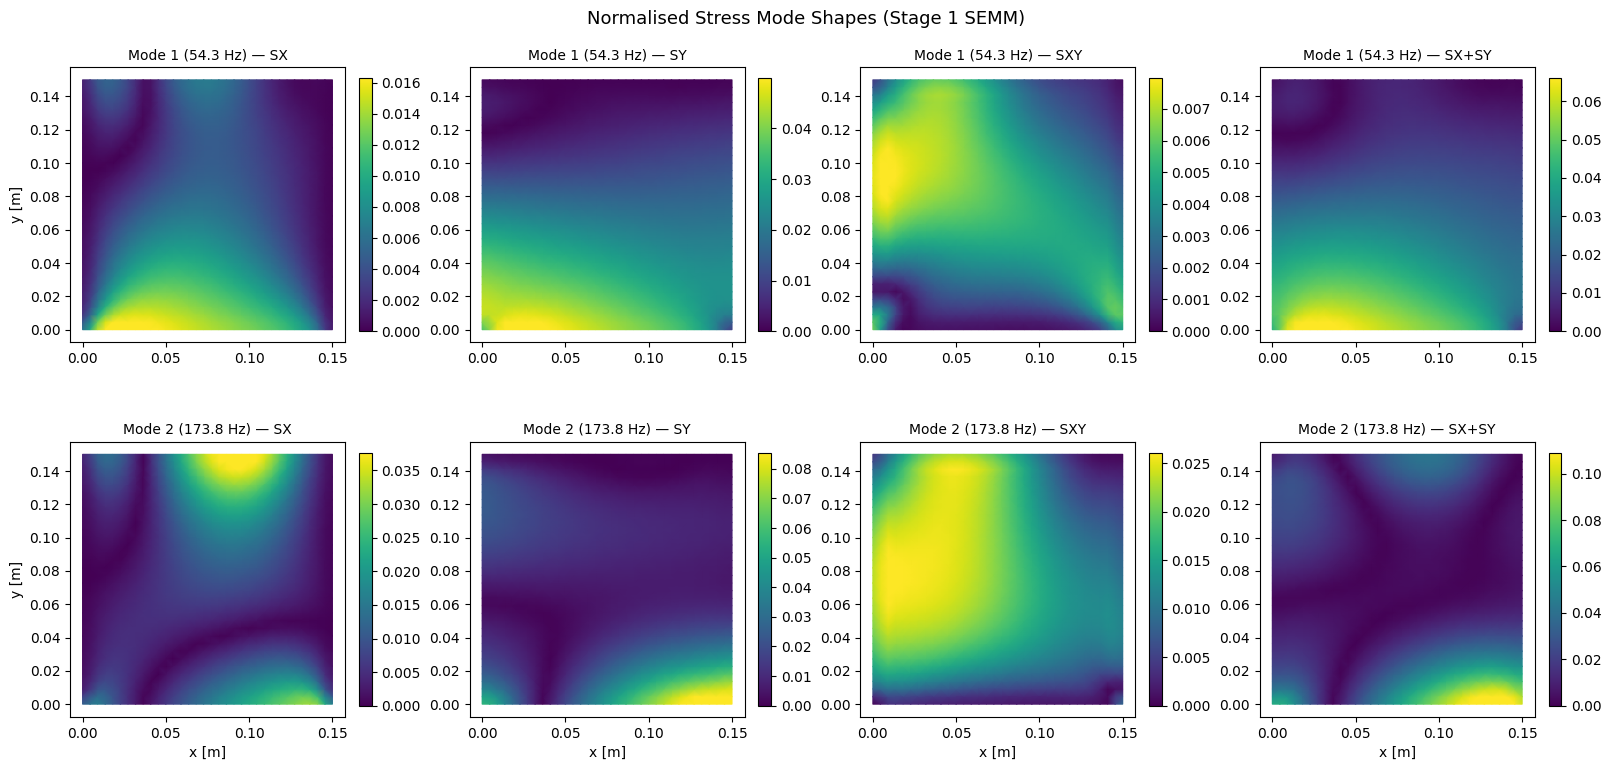

In [60]:
# ---- Visualise mode shapes ----
fig, axes = plt.subplots(n_modes, 4, figsize=(16, 3.8 * n_modes),
                         constrained_layout=True)
if n_modes == 1:
    axes = axes[None, :]

for m in range(n_modes):
    for j, (ci, cl) in enumerate(COMPS.items()):
        ax = axes[m, j]
        vals = mode_shapes[cl][:, m]
        vmin, vmax = safe_clim(vals)
        tc = ax.tripcolor(tri, vals, shading='gouraud', cmap='viridis',
                          vmin=vmin, vmax=vmax)
        plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04)
        ax.set_aspect('equal')
        ax.set_title(f'Mode {m+1} ({f_peaks[m]:.1f} Hz) — {cl}', fontsize=10)
        if j == 0:
            ax.set_ylabel('y [m]')
        if m == n_modes - 1:
            ax.set_xlabel('x [m]')

fig.suptitle('Normalised Stress Mode Shapes (Stage 1 SEMM)', fontsize=13, y=1.01)
plt.show()

---
## 3 &mdash; Load & Preprocess Camera Data

In [61]:
from fasthcc import read_hcc

images_raw, _meta = read_hcc(str(CAMERA_HCC_PATH), calibrated=True, metadata=True)
images_raw = np.asarray(images_raw, dtype=np.float64)
print(f'Camera raw       : {images_raw.shape}')

# Time-align: trim leading camera frames that precede the accelerometer recording
if CAM_LEAD_FRAMES > 0:
    images_raw = images_raw[CAM_LEAD_FRAMES:]
    print(f'After alignment  : {images_raw.shape}  (trimmed {CAM_LEAD_FRAMES} leading frames)')

if FLIP_VERTICAL:
    images_raw = images_raw[:, ::-1, :]

images_crop = SEMMThermoelasticPipeline.crop_video(images_raw, CROP)
images_red  = SEMMThermoelasticPipeline.reduce_resolution(images_crop, REDUCE_FACTOR, mode='crop')

n_frames, rows_cam, cols_cam = images_red.shape
n_pixels = rows_cam * cols_cam
print(f'After crop+reduce: {images_red.shape}  ({n_pixels} pixels)')

# Remove DC  &  convert to stress
images_ac = images_red - images_red.mean(axis=0, keepdims=True)
factor_pa_per_k = SEMMThermoelasticPipeline._camera_to_stress_factor_pa_per_k()
sigma_cam_2d = (images_ac * factor_pa_per_k).reshape(n_frames, -1)   # (n_frames, n_pixels) Pa

print(f'Stress factor    : {factor_pa_per_k:.2f} Pa/K')
print(f'sigma_cam_2d     : {sigma_cam_2d.shape}')
print(f'Duration         : {n_frames / FS_IR:.3f} s')

# ---- Camera pixel -> FE node mapping ----
x_range = mapping_meta['diag_cam']['x_range']
y_range = mapping_meta['diag_cam']['y_range']
xs = np.linspace(x_range[0], x_range[1], cols_cam)
ys = np.linspace(y_range[1], y_range[0], rows_cam)
xx, yy = np.meshgrid(xs, ys)
cam_positions = np.column_stack([xx.ravel(), yy.ravel()])

d2 = np.sum((cam_positions[:, None, :] - node_coords[None, :, :2]) ** 2, axis=2)
cam_to_node = np.argmin(d2, axis=1)
print(f'Pixel-to-node map: {n_pixels} px -> {len(np.unique(cam_to_node))} unique nodes')

Camera raw       : (12000, 132, 128)
After alignment  : (11951, 132, 128)  (trimmed 49 leading frames)
After crop+reduce: (11951, 34, 34)  (1156 pixels)
Stress factor    : -360403117.56 Pa/K
sigma_cam_2d     : (11951, 1156)
Duration         : 5.976 s
Pixel-to-node map: 1156 px -> 1156 unique nodes


---
## 4 &mdash; Compute Camera Stress PSD

Straightforward Welch auto-spectrum of the camera stress signal:
$$S_\text{cam}(f,x) = G_{yy}(f,x) = |H(f,x)|^2 \cdot S_{aa}(f) + S_{nn}(f,x)$$

This directly gives the measured stress PSD for SX+SY &mdash; **no accelerometer involved**.

### Key difference from transmissibility method

The transmissibility notebook computes $T_{H1} = G_{\sigma a}/G_{aa}$, which uses
the cross-spectrum to remove camera noise. Here we use the **auto-spectrum**
$G_{yy}$ directly. The auto-spectrum includes the noise floor $S_{nn}$.

At resonance where SNR is high ($|H|^2 S_{aa} \gg S_{nn}$), this makes little
difference. Away from resonance, the noise floor dominates $G_{yy}$, but that's
where the structural response is negligible anyway.

The practical consequence: the NNLS decomposition in the next section fits $G_{yy}$
(signal + noise), so the $\beta_r$ coefficients include a noise contribution.
This makes the self-consistency check look excellent (expanded ≈ measured) but
means the result is not purely structural.

In [62]:
seg_len = int(2 * n_frames / (N_SEGMENTS + 1))
df_welch = FS_IR / seg_len

f_welch, S_cam_pix = welch(
    sigma_cam_2d, fs=FS_IR, nperseg=seg_len, window='hann',
    axis=0, detrend='constant', scaling='density',
)
print(f'Welch segment    : {seg_len} samples  ({seg_len/FS_IR*1e3:.1f} ms)')
print(f'df               : {df_welch:.3f} Hz')
print(f'S_cam_pix shape  : {S_cam_pix.shape}  [Pa^2/Hz]')

# Band-limit
band = (f_welch >= F_MIN) & (f_welch <= F_MAX)
f_b      = f_welch[band]
S_cam_b  = S_cam_pix[band]     # (n_freq_b, n_pixels)
n_freq_b = len(f_b)

print(f'Band-limited     : {n_freq_b} lines,  {f_b[0]:.1f} .. {f_b[-1]:.1f} Hz')

# Map pixel PSD to FE nodes
S_cam_nodes = np.zeros((n_freq_b, n_nodes))
for k in range(n_freq_b):
    S_cam_nodes[k] = camera_to_nodes(S_cam_b[k], cam_to_node, n_nodes)

print(f'S_cam_nodes      : {S_cam_nodes.shape}')

# ---- Detect Stage 2 resonance peaks (local max near each Stage 1 mode) ----
rms_s2 = np.sqrt(np.mean(S_cam_nodes, axis=1))
f_peaks_s1 = f_peaks.copy()   # preserve Stage 1 frequencies

f_res_s2 = np.zeros(n_modes)
for m in range(n_modes):
    mask = np.abs(f_b - f_peaks_s1[m]) <= PEAK_DISTANCE_HZ
    if np.any(mask):
        f_res_s2[m] = f_b[mask][np.argmax(rms_s2[mask])]
    else:
        f_res_s2[m] = f_peaks_s1[m]

f_peaks = f_res_s2   # use Stage 2 frequencies for all subsequent analysis

print(f'\nStage 1 peaks : {np.round(f_peaks_s1, 1)} Hz')
print(f'Stage 2 peaks : {np.round(f_peaks, 1)} Hz')
print(f'Shift         : {np.round(f_peaks - f_peaks_s1, 2)} Hz')

Welch segment    : 3983 samples  (1991.5 ms)
df               : 0.502 Hz
S_cam_pix shape  : (1992, 1156)  [Pa^2/Hz]
Band-limited     : 498 lines,  50.2 .. 299.8 Hz
S_cam_nodes      : (498, 1156)

Stage 1 peaks : [ 54.3 173.8] Hz
Stage 2 peaks : [ 53.7 175.2] Hz
Shift         : [-0.61  1.41] Hz


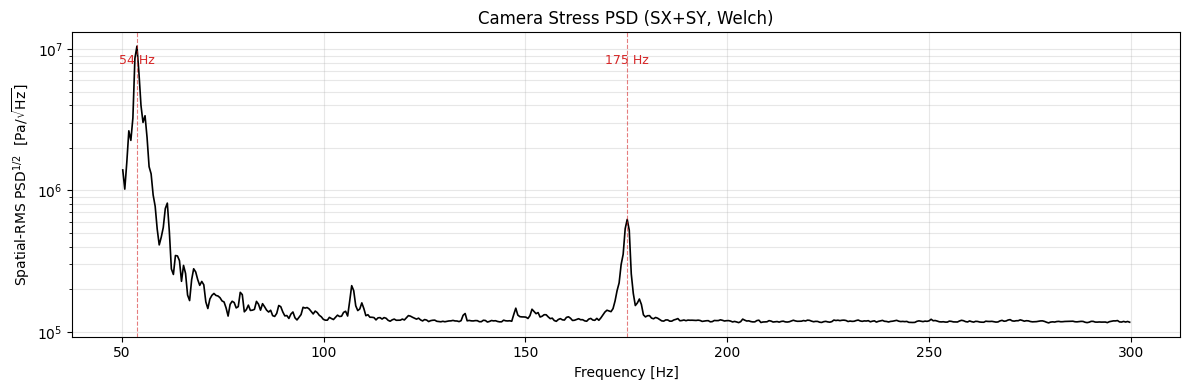

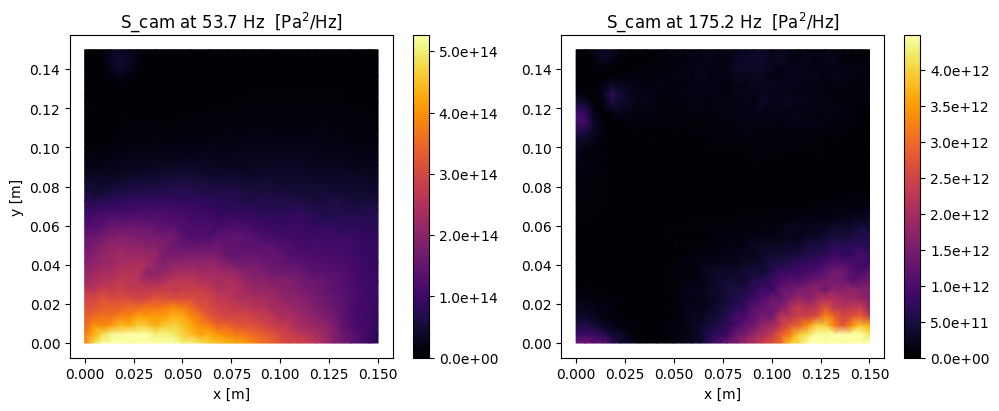

In [63]:
# ---- Camera PSD overview ----
rms_cam = np.sqrt(np.mean(S_cam_nodes, axis=1))   # spatial RMS

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(f_b, rms_cam, 'k', lw=1.2)
for m, fp in enumerate(f_peaks):
    ax.axvline(fp, color='C3', ls='--', lw=0.8, alpha=0.6)
    ax.text(fp, ax.get_ylim()[1] * 0.7, f'{fp:.0f} Hz',
            ha='center', va='top', fontsize=9, color='C3')
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Spatial-RMS PSD$^{1/2}$  [Pa/$\\sqrt{\\mathrm{Hz}}$]')
ax.set_title('Camera Stress PSD (SX+SY, Welch)')
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# ---- Spatial maps at resonances ----
fig, axes = plt.subplots(1, n_modes, figsize=(5 * n_modes, 4),
                         constrained_layout=True)
if n_modes == 1:
    axes = [axes]

for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    ax = axes[m]
    vals = S_cam_nodes[k_res]
    vmin, vmax = safe_clim(vals)
    tc = ax.tripcolor(tri, vals, shading='gouraud', cmap='inferno',
                      vmin=vmin, vmax=vmax)
    plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04, format='%.1e')
    ax.set_aspect('equal')
    ax.set_title(f'S_cam at {f_b[k_res]:.1f} Hz  [Pa$^2$/Hz]')
    ax.set_xlabel('x [m]')
    if m == 0:
        ax.set_ylabel('y [m]')

plt.show()

---
## 4b &mdash; Virtual Reference Denoising (camera as its own reference)

The raw Welch auto-spectrum $G_{yy}$ includes camera noise. Normally, removing
this noise requires an external reference (accelerometer + H1 estimator).

**Key insight:** The camera itself can serve as its own reference. Each pixel
measures the same structural vibration plus independent noise. By averaging all
pixels into a **virtual reference** $r(t)$, the noise is reduced by $\sqrt{N}$
(with $N = 930$ pixels, that's a 30× reduction). Cross-correlating each pixel
with this near-clean reference removes the remaining pixel noise:

$$S_\text{clean}(f,x) = \frac{|G_{xr}(f)|^2}{G_{rr}(f)} \approx |H(f,x)|^2 \cdot S_{aa}(f)$$

This gives the **noise-free structural PSD** — the same quantity that the
transmissibility method achieves via H1 with an accelerometer — but using only
camera data.

### Why this works

- **Signal** (structural vibration): correlated across all pixels → survives cross-spectral averaging
- **Noise** (pixel-level fluctuations): independent between pixels → cancels in cross-spectrum

This is the same principle as the H1 estimator, except the "reference sensor"
is synthesised from the camera itself rather than being a separate accelerometer.

In [64]:
# ---- Compute denoised PSD via virtual reference ----
print(f'Computing virtual reference denoised PSD ({n_pixels} pixels) ...')
f_vref, S_clean_pix, S_rr, coh_vref_pix, n_avg_vref = compute_vref_denoised_psd(
    sigma_cam_2d, FS_IR, seg_len,
)
print(f'Virtual reference averages : {n_avg_vref}')
print(f'Noise reduction factor     : sqrt({n_pixels}) = {np.sqrt(n_pixels):.1f}x')

# Band-limit
band_vr = (f_vref >= F_MIN) & (f_vref <= F_MAX)
S_clean_b = S_clean_pix[band_vr]         # (n_freq_b, n_pixels)
coh_vref_b = coh_vref_pix[band_vr]
f_vr_b = f_vref[band_vr]

# Map denoised PSD from pixels to FE nodes
S_denoised_nodes = np.zeros((n_freq_b, n_nodes))
coh_vref_nodes = np.zeros((n_freq_b, n_nodes))
for k in range(n_freq_b):
    S_denoised_nodes[k] = camera_to_nodes(S_clean_b[k], cam_to_node, n_nodes)
    coh_vref_nodes[k] = camera_to_nodes(coh_vref_b[k], cam_to_node, n_nodes)

print(f'S_denoised_nodes : {S_denoised_nodes.shape}')

# ---- Compare raw vs denoised at resonances ----
for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    raw_rms = np.sqrt(np.mean(S_cam_nodes[k_res]))
    den_rms = np.sqrt(np.mean(S_denoised_nodes[k_res]))
    ratio = den_rms / (raw_rms + 1e-30)
    noise_pct = (1 - ratio**2) * 100
    print(f'  Mode {m+1} ({f_peaks[m]:.1f} Hz):  raw = {raw_rms:.2e},  denoised = {den_rms:.2e},'
          f'  ratio = {ratio:.3f},  noise fraction = {noise_pct:.1f}%')

Computing virtual reference denoised PSD (1156 pixels) ...
Virtual reference averages : 5
Noise reduction factor     : sqrt(1156) = 34.0x
S_denoised_nodes : (498, 1156)
  Mode 1 (53.7 Hz):  raw = 1.05e+07,  denoised = 1.05e+07,  ratio = 1.000,  noise fraction = -0.0%
  Mode 2 (175.2 Hz):  raw = 6.24e+05,  denoised = 6.11e+05,  ratio = 0.979,  noise fraction = 4.1%


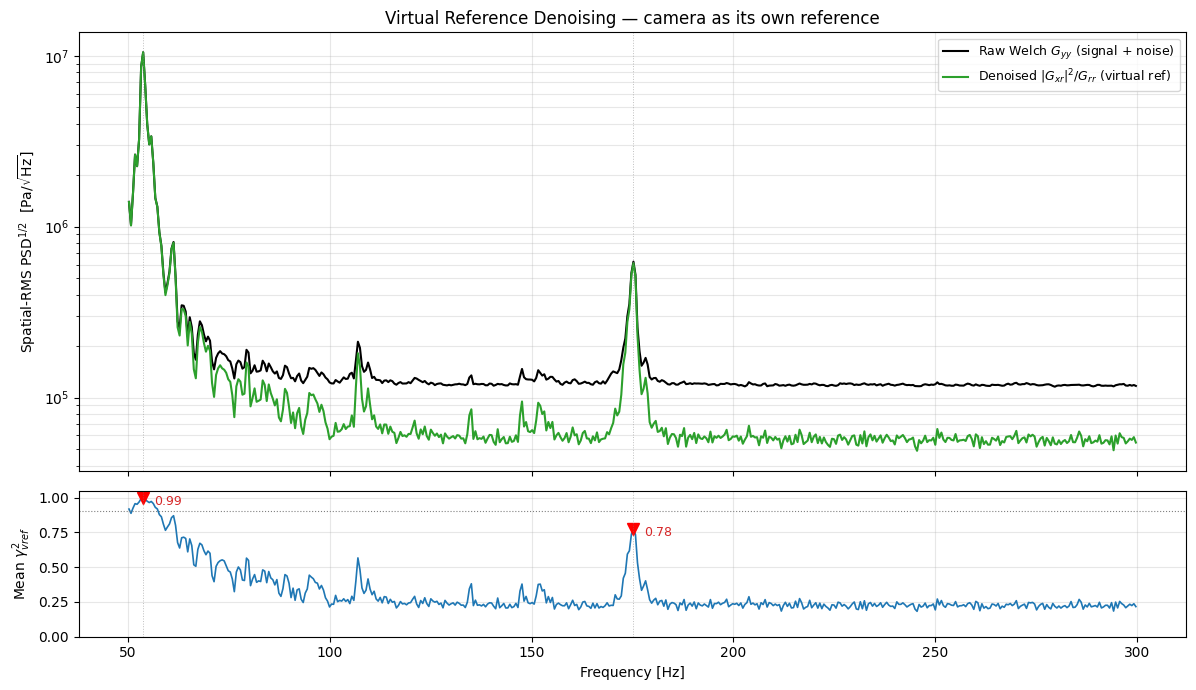

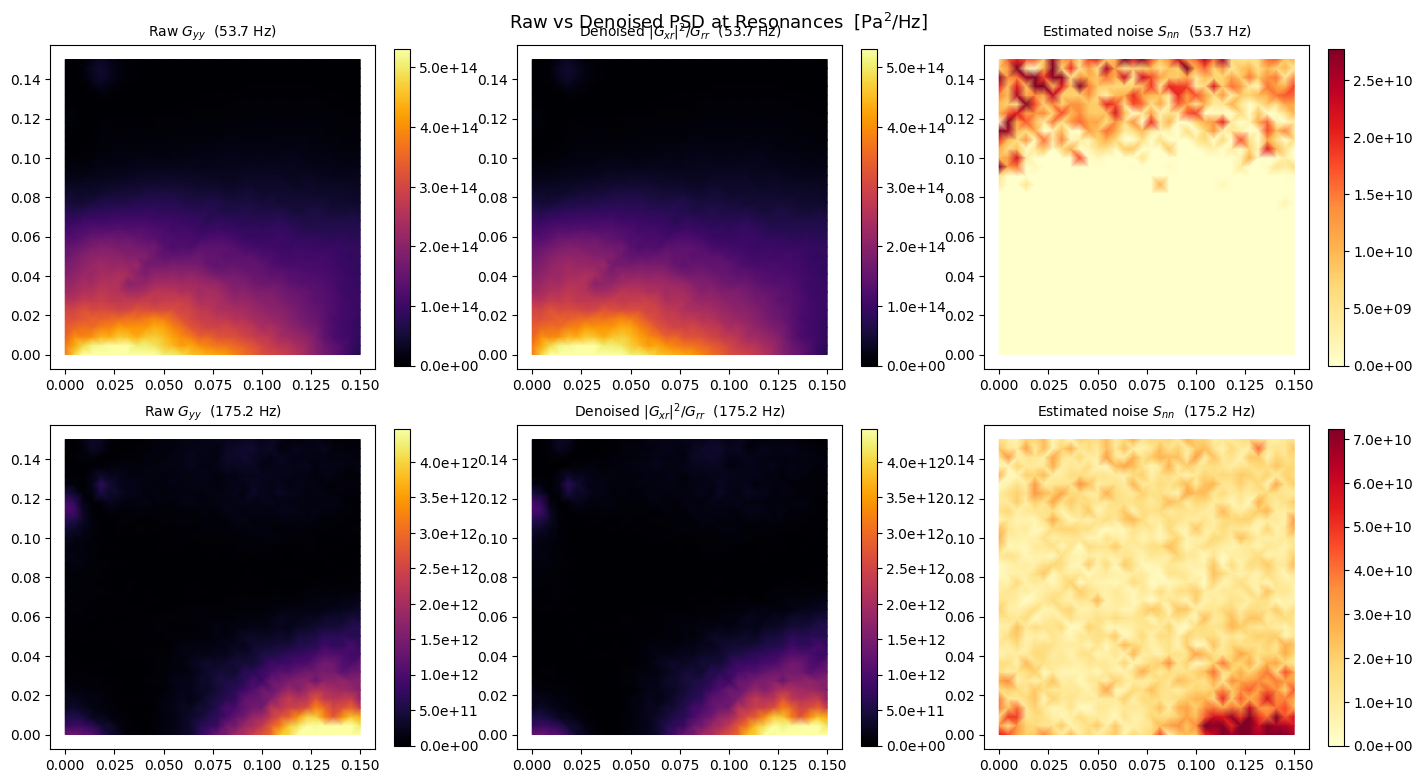

In [65]:
# ---- Comparison: raw vs denoised PSD ----
rms_raw = np.sqrt(np.mean(S_cam_nodes, axis=1))
rms_denoised = np.sqrt(np.mean(S_denoised_nodes, axis=1))
coh_vref_mean = np.mean(coh_vref_nodes, axis=1)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.semilogy(f_b, rms_raw,      'k',    lw=1.5, label='Raw Welch $G_{yy}$ (signal + noise)')
ax1.semilogy(f_b, rms_denoised, 'C2-',  lw=1.5, label='Denoised $|G_{xr}|^2/G_{rr}$ (virtual ref)')
for fp in f_peaks:
    ax1.axvline(fp, color='grey', ls=':', lw=0.7, alpha=0.5)
ax1.set_ylabel('Spatial-RMS PSD$^{1/2}$  [Pa/$\\sqrt{\\mathrm{Hz}}$]')
ax1.set_title('Virtual Reference Denoising — camera as its own reference')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, which='both')

# Coherence with virtual reference
ax2.plot(f_b, coh_vref_mean, 'C0', lw=1.2)
for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    ax2.plot(f_peaks[m], coh_vref_mean[k_res], 'rv', ms=8)
    ax2.annotate(f'{coh_vref_mean[k_res]:.2f}', (f_peaks[m], coh_vref_mean[k_res]),
                 textcoords='offset points', xytext=(8, -5), fontsize=9, color='C3')
ax2.axhline(0.9, color='grey', ls=':', lw=0.8)
for fp in f_peaks:
    ax2.axvline(fp, color='grey', ls=':', lw=0.7, alpha=0.5)
ax2.set_ylabel('Mean $\\gamma^2_{vref}$')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(0, 1.05)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Spatial comparison: raw vs denoised at resonances ----
fig, axes = plt.subplots(n_modes, 3, figsize=(14, 3.8 * n_modes),
                         constrained_layout=True)
if n_modes == 1:
    axes = axes[None, :]

for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    raw_vals = S_cam_nodes[k_res]
    den_vals = S_denoised_nodes[k_res]
    noise_est = np.maximum(raw_vals - den_vals, 0)

    vmin, vmax = safe_clim(np.concatenate([raw_vals, den_vals]))

    for j, (vals, title, cm) in enumerate([
        (raw_vals,  'Raw $G_{yy}$',              'inferno'),
        (den_vals,  'Denoised $|G_{xr}|^2/G_{rr}$', 'inferno'),
        (noise_est, 'Estimated noise $S_{nn}$',  'YlOrRd'),
    ]):
        ax = axes[m, j]
        if j < 2:
            vm = (vmin, vmax)
        else:
            vm = safe_clim(noise_est)
        tc = ax.tripcolor(tri, vals, shading='gouraud', cmap=cm,
                          vmin=vm[0], vmax=vm[1])
        plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04, format='%.1e')
        ax.set_aspect('equal')
        ax.set_title(f'{title}  ({f_b[k_res]:.1f} Hz)', fontsize=10)

fig.suptitle('Raw vs Denoised PSD at Resonances  [Pa$^2$/Hz]', fontsize=13, y=1.01)
plt.show()

---
## 5 &mdash; PSD-Weighted NNLS Modal Decomposition

At each frequency, solve the **non-negative least squares** problem with
**PSD-level weighting** on the **denoised** PSD from Section 4b:

$$\beta(f) = \arg\min_{\beta \ge 0} \sum_x w(f,x)\,\bigl[S_\text{clean}(f,x) - \sum_r \beta_r(f)\,|\hat\psi_{r,\text{cam}}(x)|^2\bigr]^2$$

where $w(f,x) = S_\text{clean}(f,x) / \max_x S_\text{clean}(f,x)$.

### Why PSD weighting helps

The weighting adapts spatially with frequency &mdash; near each resonance,
the antinodes of the dominant mode have the highest PSD and therefore the
most influence on the fit. Pixels at nodal lines (low PSD, high noise fraction)
are downweighted. This is analogous to coherence weighting in the transmissibility
method, but without needing a reference signal.

### Denoised input &rarr; noise-free output

By feeding the virtual-reference-denoised PSD into the NNLS (instead of the
raw $G_{yy}$), the $\beta_r$ coefficients now represent the **noise-free
structural response**. The expanded PSD will match the denoised curve (not the
raw camera Welch).

This puts the direct PSD method on the same footing as the transmissibility
method: both produce noise-free structural stress PSD. The direct PSD method
achieves this without an accelerometer by using the camera's spatial redundancy
as a built-in denoising mechanism (virtual reference).

In [66]:
# ---- Build squared mode shape basis ----
Phi = {}
for label in COMPS.values():
    Phi[label] = mode_shapes[label] ** 2   # (n_nodes, n_modes)  real >= 0

Phi_cam = Phi['SX+SY']   # (n_nodes, n_modes)
print(f'Phi_cam shape : {Phi_cam.shape}')
print(f'Condition     : {np.linalg.cond(Phi_cam):.1f}')

# ---- PSD-weighted NNLS decomposition on DENOISED PSD ----
# Using the virtual-reference-denoised PSD instead of raw Gyy.
# This means the beta coefficients represent the noise-free structural response,
# not the total (signal+noise) level. The expanded PSD will match the denoised
# curve, not the raw camera Welch.
print('\nRunning PSD-weighted NNLS on denoised PSD ...')
beta, nnls_residual = nnls_decomposition(S_denoised_nodes, Phi_cam, weights=S_denoised_nodes)

# ---- Reconstruction ----
S_recon = beta @ Phi_cam.T   # (n_freq_b, n_nodes)

accuracy = (1 - nnls_residual) * 100   # %  (100% = perfect)

print(f'beta shape    : {beta.shape}')

# ---- Print per-mode reconstruction accuracy at resonances ----
print(f'\nReconstruction accuracy at resonances (denoised, PSD-weighted):')
for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    print(f'  Mode {m+1} ({f_peaks[m]:.1f} Hz):  accuracy = {accuracy[k_res]:.1f}%,  '
          f'beta = {beta[k_res, m]:.4e}')

Phi_cam shape : (1156, 2)
Condition     : 2.0

Running PSD-weighted NNLS on denoised PSD ...
beta shape    : (498, 2)

Reconstruction accuracy at resonances (denoised, PSD-weighted):
  Mode 1 (53.7 Hz):  accuracy = 89.2%,  beta = 1.2281e+17
  Mode 2 (175.2 Hz):  accuracy = 72.5%,  beta = 3.7491e+14


Mode 1 antinode : node 6  at (0.023, 0.000) m
Mode 2 antinode : node 31  at (0.136, 0.000) m
Nodal line      : node 34 at (0.150, 0.150) m


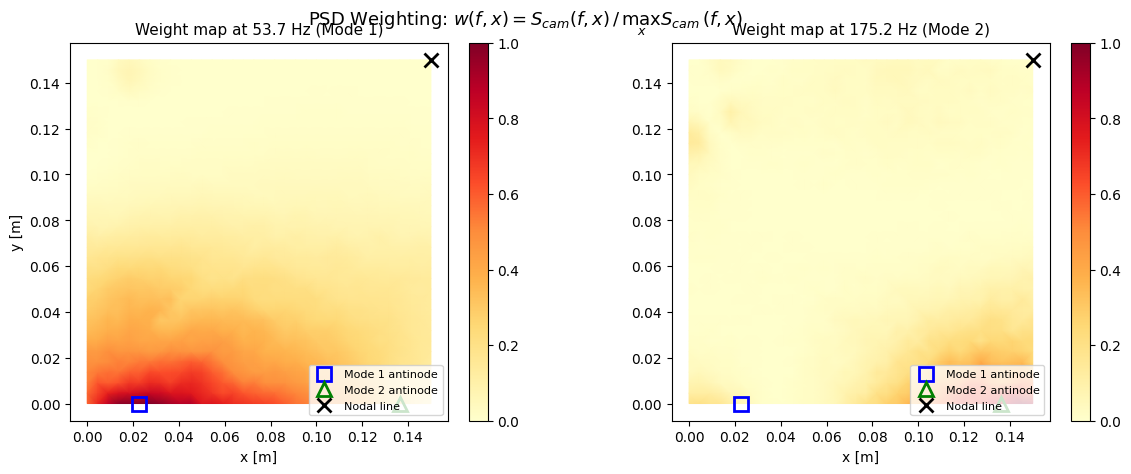

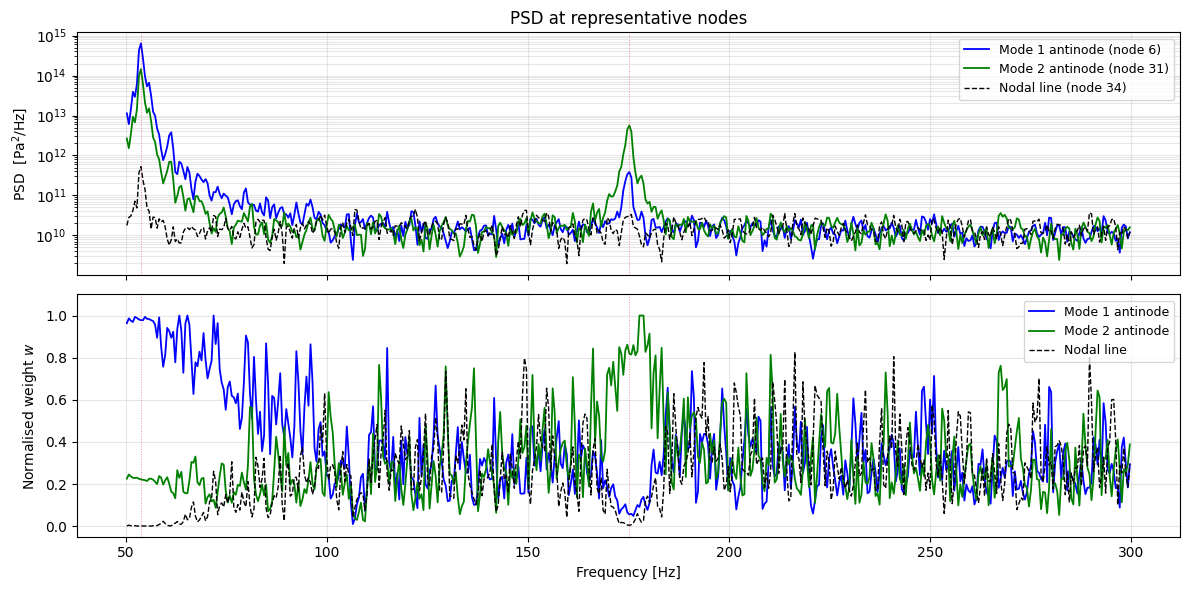

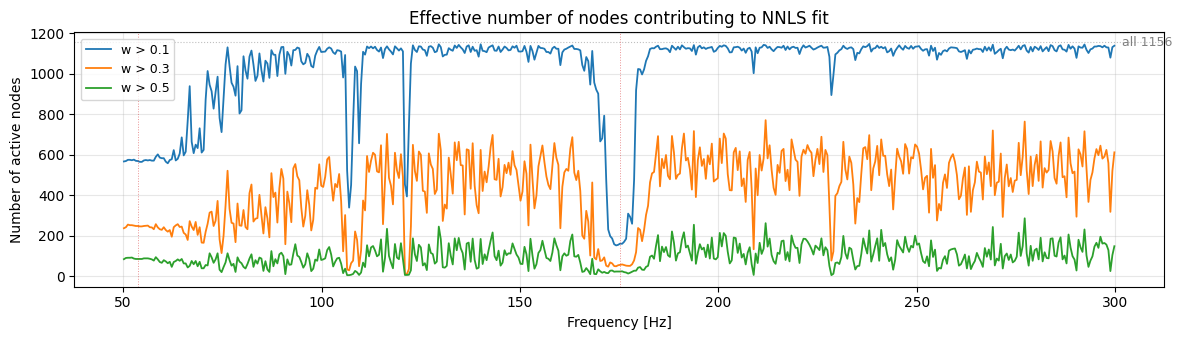

In [67]:
# ==============================================================================
#  Visualise PSD weighting effect
# ==============================================================================

# ---- Compute normalised weight maps: w(f,x) = S_cam(f,x) / max_x S_cam(f,x) ----
W_norm = S_cam_nodes / (S_cam_nodes.max(axis=1, keepdims=True) + 1e-30)  # (n_freq_b, n_nodes), [0..1]

# ---- Pick representative nodes ----
node_m1 = np.argmax(Psi_cam[:, 0])                           # mode 1 antinode
node_m2 = np.argmax(Psi_cam[:, 1])                           # mode 2 antinode
psi_max = np.max(Psi_cam, axis=1)                             # max mode shape across modes
node_low = np.argmin(psi_max)                                  # nodal line (low for all modes)

print(f'Mode 1 antinode : node {node_m1}  at ({node_coords[node_m1, 0]:.3f}, {node_coords[node_m1, 1]:.3f}) m')
print(f'Mode 2 antinode : node {node_m2}  at ({node_coords[node_m2, 0]:.3f}, {node_coords[node_m2, 1]:.3f}) m')
print(f'Nodal line      : node {node_low} at ({node_coords[node_low, 0]:.3f}, {node_coords[node_low, 1]:.3f}) m')

# ---- PLOT 1: Spatial weight maps at resonances ----
fig, axes = plt.subplots(1, n_modes, figsize=(6 * n_modes, 4.5), constrained_layout=True)
if n_modes == 1:
    axes = [axes]

for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    ax = axes[m]
    tc = ax.tripcolor(tri, W_norm[k_res], shading='gouraud', cmap='YlOrRd',
                      vmin=0, vmax=1)
    plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04)
    # Mark representative nodes
    ax.plot(*node_coords[node_m1, :2], 'bs', ms=10, mew=2, mfc='none', label=f'Mode 1 antinode')
    ax.plot(*node_coords[node_m2, :2], 'g^', ms=10, mew=2, mfc='none', label=f'Mode 2 antinode')
    ax.plot(*node_coords[node_low, :2], 'kx', ms=10, mew=2, label=f'Nodal line')
    ax.set_aspect('equal')
    ax.set_title(f'Weight map at {f_b[k_res]:.1f} Hz (Mode {m+1})', fontsize=11)
    ax.set_xlabel('x [m]')
    if m == 0:
        ax.set_ylabel('y [m]')
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('PSD Weighting: $w(f,x) = S_{cam}(f,x) \\,/\\, \\max_x S_{cam}(f,x)$',
             fontsize=13, y=1.02)
plt.show()

# ---- PLOT 2: Weight spectrum at representative nodes ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1]})

# Top: PSD at the three nodes (shows why the weight shifts)
ax1.semilogy(f_b, S_cam_nodes[:, node_m1], 'b-',  lw=1.3, label=f'Mode 1 antinode (node {node_m1})')
ax1.semilogy(f_b, S_cam_nodes[:, node_m2], 'g-',  lw=1.3, label=f'Mode 2 antinode (node {node_m2})')
ax1.semilogy(f_b, S_cam_nodes[:, node_low], 'k--', lw=1,   label=f'Nodal line (node {node_low})')
for fp in f_peaks:
    ax1.axvline(fp, color='C3', ls=':', lw=0.7, alpha=0.5)
ax1.set_ylabel('PSD  [Pa$^2$/Hz]')
ax1.set_title('PSD at representative nodes')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, which='both')

# Bottom: normalised weight at the three nodes
ax2.plot(f_b, W_norm[:, node_m1], 'b-',  lw=1.3, label=f'Mode 1 antinode')
ax2.plot(f_b, W_norm[:, node_m2], 'g-',  lw=1.3, label=f'Mode 2 antinode')
ax2.plot(f_b, W_norm[:, node_low], 'k--', lw=1,   label=f'Nodal line')
for fp in f_peaks:
    ax2.axvline(fp, color='C3', ls=':', lw=0.7, alpha=0.5)
ax2.set_ylabel('Normalised weight $w$')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(-0.05, 1.1)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- PLOT 3: Effective number of contributing nodes vs frequency ----
# Count nodes with weight > threshold (e.g. 0.1, 0.3, 0.5)
thresholds = [0.1, 0.3, 0.5]
fig, ax = plt.subplots(figsize=(12, 3.5))
for thr in thresholds:
    n_active = np.sum(W_norm > thr, axis=1)
    ax.plot(f_b, n_active, lw=1.3, label=f'w > {thr:.1f}')
ax.axhline(n_nodes, color='grey', ls=':', lw=0.8, alpha=0.5)
ax.text(f_b[-1], n_nodes, f'  all {n_nodes}', va='center', fontsize=9, color='grey')
for fp in f_peaks:
    ax.axvline(fp, color='C3', ls=':', lw=0.7, alpha=0.5)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Number of active nodes')
ax.set_title('Effective number of nodes contributing to NNLS fit')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

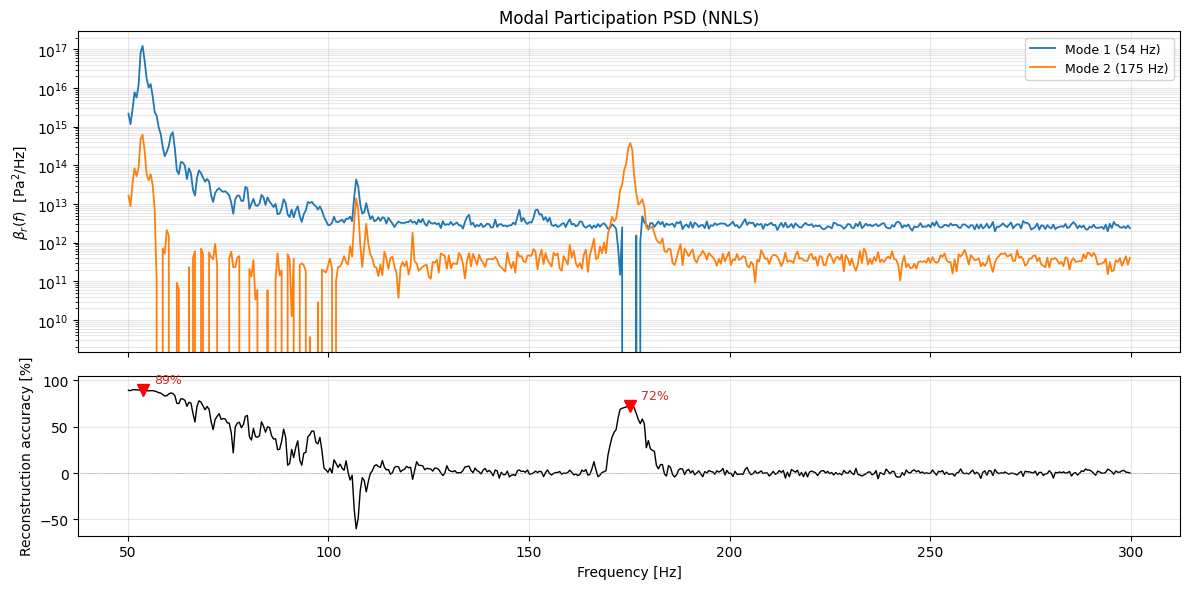

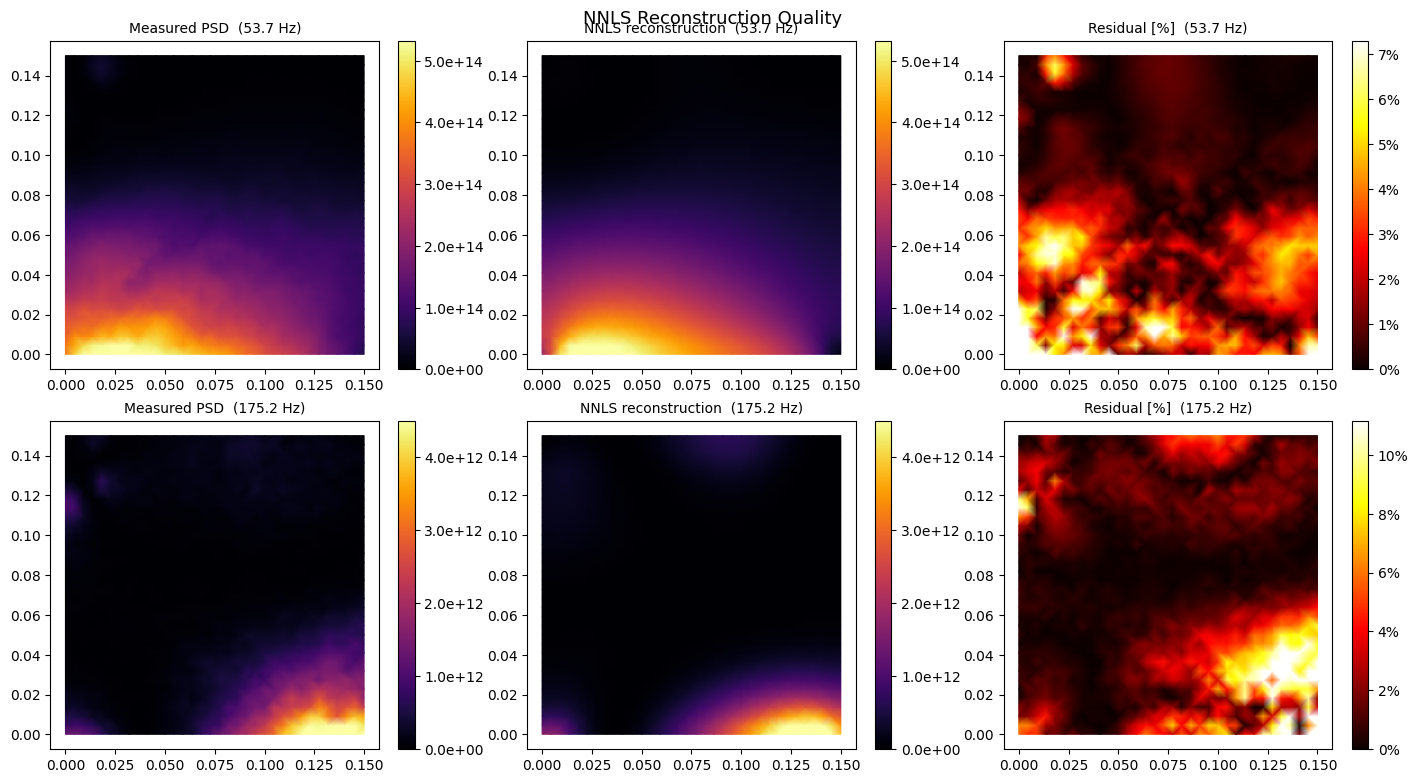

In [68]:
# ---- Modal participation spectra ----
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

for m in range(n_modes):
    ax1.semilogy(f_b, beta[:, m], lw=1.3,
                 label=f'Mode {m+1} ({f_peaks[m]:.0f} Hz)')
ax1.set_ylabel('$\\beta_r(f)$  [Pa$^2$/Hz]')
ax1.set_title('Modal Participation PSD (NNLS)')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, which='both')

ax2.plot(f_b, accuracy, 'k', lw=1)
for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    ax2.plot(f_b[k_res], accuracy[k_res], 'rv', ms=8)
    ax2.annotate(f'{accuracy[k_res]:.0f}%', (f_b[k_res], accuracy[k_res]),
                 textcoords='offset points', xytext=(8, 5), fontsize=9, color='C3')
ax2.set_ylabel('Reconstruction accuracy [%]')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(None, 105)
ax2.axhline(0, color='grey', ls=':', lw=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Spatial comparison: measured vs reconstructed at resonances ----
fig, axes = plt.subplots(n_modes, 3, figsize=(14, 3.8 * n_modes),
                         constrained_layout=True)
if n_modes == 1:
    axes = axes[None, :]

for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    meas  = S_cam_nodes[k_res]
    recon = S_recon[k_res]
    resid_pct = 100 * np.abs(meas - recon) / (meas.max() + 1e-30)

    vmin, vmax = safe_clim(np.concatenate([meas, recon]))

    for j, (vals, title, cm, fmt) in enumerate([
        (meas,      'Measured PSD',         'inferno', '%.1e'),
        (recon,     'NNLS reconstruction',  'inferno', '%.1e'),
        (resid_pct, 'Residual [%]',         'hot',     '%.0f%%'),
    ]):
        ax = axes[m, j]
        if j < 2:
            vm = (vmin, vmax)
        else:
            vm = (0, min(np.percentile(resid_pct[np.isfinite(resid_pct)], 98), 100))
        tc = ax.tripcolor(tri, vals, shading='gouraud', cmap=cm,
                          vmin=vm[0], vmax=vm[1])
        plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04,
                     format=fmt if fmt else None)
        ax.set_aspect('equal')
        ax.set_title(f'{title}  ({f_b[k_res]:.1f} Hz)', fontsize=10)

fig.suptitle('NNLS Reconstruction Quality', fontsize=13, y=1.01)
plt.show()

---
## 6 &mdash; Multi-Component Expansion

The modal participation $\beta_r(f)$ is the **same** for every stress component.
Only the squared mode shapes change:
$$S_c(f,x) = \sum_r \beta_r(f) \; |\hat\psi_{r,c}(x)|^2$$

In [69]:
S_stress = {}  # label -> (n_freq_b, n_nodes)
for label in COMPS.values():
    S_stress[label] = beta @ Phi[label].T     # (n_freq_b, n_nodes)

print('Expanded stress PSD shapes:')
for label, S in S_stress.items():
    print(f'  S_{label:5s} : {S.shape}  [Pa^2/Hz]')

Expanded stress PSD shapes:
  S_SX    : (498, 1156)  [Pa^2/Hz]
  S_SY    : (498, 1156)  [Pa^2/Hz]
  S_SXY   : (498, 1156)  [Pa^2/Hz]
  S_SX+SY : (498, 1156)  [Pa^2/Hz]


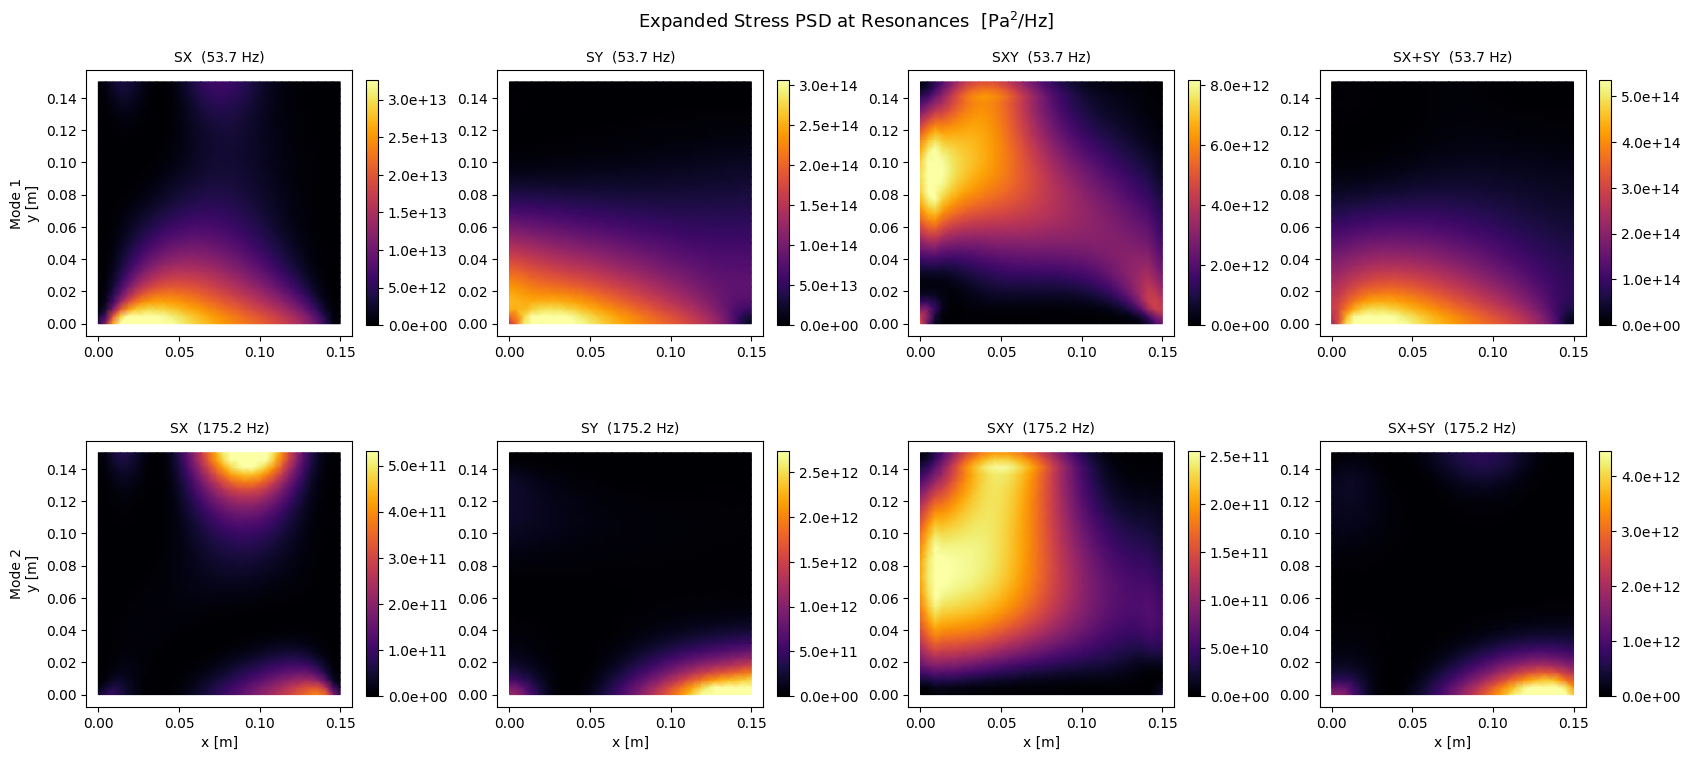

In [70]:
# ---- Stress PSD spatial maps at resonances ----
comp_list = list(COMPS.values())
n_comp = len(comp_list)

fig, axes = plt.subplots(n_modes, n_comp, figsize=(4.2 * n_comp, 3.8 * n_modes),
                         constrained_layout=True)
if n_modes == 1:
    axes = axes[None, :]

for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    for j, label in enumerate(comp_list):
        ax = axes[m, j]
        vals = S_stress[label][k_res]
        vmin, vmax = safe_clim(vals)
        tc = ax.tripcolor(tri, vals, shading='gouraud', cmap='inferno',
                          vmin=vmin, vmax=vmax)
        plt.colorbar(tc, ax=ax, fraction=0.046, pad=0.04, format='%.1e')
        ax.set_aspect('equal')
        ax.set_title(f'{label}  ({f_b[k_res]:.1f} Hz)', fontsize=10)
        if j == 0:
            ax.set_ylabel(f'Mode {m+1}\ny [m]')
        if m == n_modes - 1:
            ax.set_xlabel('x [m]')

fig.suptitle('Expanded Stress PSD at Resonances  [Pa$^2$/Hz]', fontsize=13, y=1.01)
plt.show()

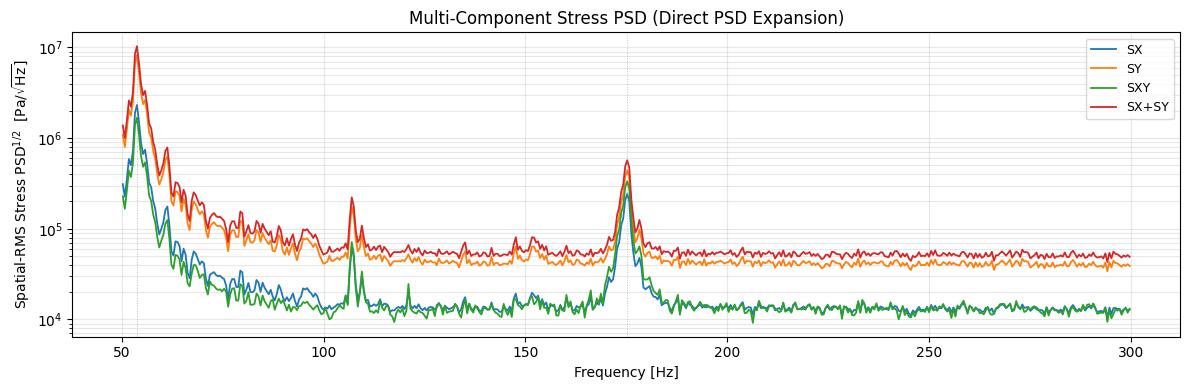

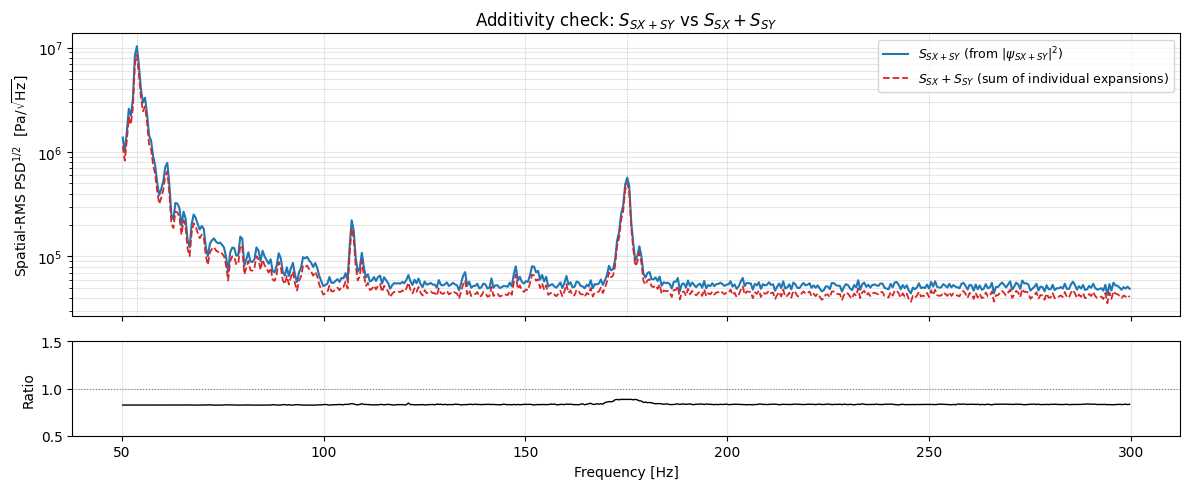

Mode shape additivity: ||psi_SX + psi_SY - psi_SX+SY|| / ||psi_SX+SY||
(Note: direct PSD uses |H| mode shapes, so |H_SX|+|H_SY| != |H_SX+SY| in general)
  Mode 1 (53.7 Hz):  relative error = 0.0074  (0.7%)
  Mode 2 (175.2 Hz):  relative error = 0.2954  (29.5%)


In [71]:
# ---- Spectral overview: spatial-RMS PSD per component ----
fig, ax = plt.subplots(figsize=(12, 4))

for label in comp_list:
    rms = np.sqrt(np.mean(S_stress[label], axis=1))   # spatial RMS
    ax.semilogy(f_b, rms, lw=1.3, label=label)

for fp in f_peaks:
    ax.axvline(fp, color='grey', ls=':', lw=0.7, alpha=0.5)

ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Spatial-RMS Stress PSD$^{1/2}$  [Pa/$\\sqrt{\\mathrm{Hz}}$]')
ax.set_title('Multi-Component Stress PSD (Direct PSD Expansion)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# ---- Additivity check: S via (Phi_SX + Phi_SY) vs S via Phi_SX+SY ----
# In the PSD domain: S_SX+SY = β @ |ψ_SX+SY|²
# while S_SX + S_SY = β @ (|ψ_SX|² + |ψ_SY|²)
# These differ by |ψ_SX+SY|² vs |ψ_SX|² + |ψ_SY|²  (cross-term).
S_sum_check = S_stress['SX'] + S_stress['SY']
rms_sum_direct = np.sqrt(np.mean(S_sum_check, axis=1))
rms_sxsy       = np.sqrt(np.mean(S_stress['SX+SY'], axis=1))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True,
                                gridspec_kw={'height_ratios': [3, 1]})

ax1.semilogy(f_b, rms_sxsy,       'C0',   lw=1.5, label='$S_{SX+SY}$ (from $|\\psi_{SX+SY}|^2$)')
ax1.semilogy(f_b, rms_sum_direct, 'C3--', lw=1.3, label='$S_{SX} + S_{SY}$ (sum of individual expansions)')
for fp in f_peaks:
    ax1.axvline(fp, color='grey', ls=':', lw=0.7, alpha=0.5)
ax1.set_ylabel('Spatial-RMS PSD$^{1/2}$  [Pa/$\\sqrt{\\mathrm{Hz}}$]')
ax1.set_title('Additivity check: $S_{SX+SY}$ vs $S_{SX} + S_{SY}$')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3, which='both')

# Ratio
ratio = rms_sum_direct / (rms_sxsy + 1e-30)
ax2.plot(f_b, ratio, 'k', lw=1)
ax2.axhline(1.0, color='grey', ls=':', lw=0.8)
ax2.set_ylabel('Ratio')
ax2.set_xlabel('Frequency [Hz]')
ax2.set_ylim(0.5, 1.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Mode shape additivity check ----
print('Mode shape additivity: ||psi_SX + psi_SY - psi_SX+SY|| / ||psi_SX+SY||')
print('(Note: direct PSD uses |H| mode shapes, so |H_SX|+|H_SY| != |H_SX+SY| in general)')
for m in range(n_modes):
    psi_sum  = mode_shapes['SX'][:, m] + mode_shapes['SY'][:, m]
    psi_sxsy = mode_shapes['SX+SY'][:, m]
    rel_err  = np.linalg.norm(psi_sum - psi_sxsy) / (np.linalg.norm(psi_sxsy) + 1e-30)
    print(f'  Mode {m+1} ({f_peaks[m]:.1f} Hz):  relative error = {rel_err:.4f}  ({rel_err*100:.1f}%)')

---
## Summary

### Outputs produced
- `S_stress[comp]` &mdash; **noise-free** stress PSD for SX, SY, SXY, SX+SY at every FE node, shape `(n_freq, n_nodes)`, units Pa$^2$/Hz
- `beta` &mdash; modal participation PSD, shape `(n_freq, n_modes)`, real $\ge 0$
- `S_denoised_nodes` &mdash; virtual-reference-denoised camera PSD (intermediate, used for NNLS input)

### Key advantage
No accelerometer required. The camera time history contains the full stress
response. Virtual reference denoising leverages the spatial redundancy of the
camera (930 pixels) to remove measurement noise via cross-spectral averaging,
then the NNLS decomposition extracts modal contributions and Stage 1 mode shapes
provide the relationship between stress components.

### Virtual reference denoising (key innovation)

The camera serves as its own reference: averaging all $N$ pixels creates a
virtual reference with $\sqrt{N}\times$ noise reduction. Cross-correlating
each pixel with this reference removes the remaining pixel noise:

$$S_\text{clean}(f,x) = \frac{|G_{xr}(f)|^2}{G_{rr}(f)} \approx |H(f,x)|^2 \cdot S_{aa}(f)$$

This achieves the same noise removal as the transmissibility method's H1 estimator,
but without requiring an accelerometer. The "secret weapon" is spatial redundancy:
841 independent sensors all measuring the same structural vibration.

### Limitations
- **Cannot separate structure from excitation.** If the excitation profile
  changes, the camera measurement must be repeated. (The transmissibility
  method avoids this by isolating the structural transfer function $T(f,x)$.)
- **Virtual reference quality depends on mode shape spatial average.** If a
  mode shape has near-zero spatial mean (highly antisymmetric), the virtual
  reference will not capture it well. For our plate modes this is not an issue.

### Final comparison: both methods with noise removal

| Aspect | Direct PSD + virtual ref (this notebook) | Transmissibility (companion) |
|--------|----------------------------------------|------------------------------|
| **Input data** | Denoised camera PSD via $|G_{xr}|^2/G_{rr}$ | H1 transmissibility $G_{\sigma a}/G_{aa}$ |
| **Reference signal** | Virtual (averaged camera pixels) | Physical (accelerometer) |
| **Noise removal** | Via inter-pixel cross-spectra | Via camera-accel cross-spectrum |
| **Result** | Noise-free structural PSD | Noise-free structural PSD |
| **Accelerometer** | Not needed | Required |
| **Excitation-dependent** | Yes (PSD baked in) | No (T is structural property) |
| **Extra hardware** | Camera only | Camera + accelerometer |

Both methods now produce noise-free structural stress PSDs. The transmissibility
method additionally separates the structural transfer function from the excitation,
making it reusable. The direct PSD method is simpler (no accelerometer) and
demonstrates that spatial redundancy from a full-field camera can replace a
dedicated reference sensor for denoising.

### Quality metrics
- Low NNLS residual confirms the mode shape basis captures the denoised PSD pattern
- MAC near 1.0 at resonances confirms spatial pattern consistency
- Self-consistency: expanded ≈ denoised (both noise-free)
- Raw Welch > denoised by factor $1/\gamma^2_{vref}$ (noise successfully removed)

---
## 7 &mdash; Validation

### Three-level comparison: Raw &rarr; Denoised &rarr; Expanded

The plot below shows three curves:

| Curve | What it represents |
|-------|--------------------|
| **Raw $G_{yy}$** (black) | Direct Welch of camera signal — includes noise |
| **Denoised** (green) | Virtual-reference PSD — noise removed via cross-spectral averaging |
| **Expanded** (red dashed) | 2-mode NNLS fit to the denoised PSD |

**Expected behaviour:**
- Green < Black → noise has been removed (gap = noise floor)
- Red ≈ Green at resonances → modal fit captures the denoised signal well
- The expanded result now represents the **noise-free structural stress PSD**

### Comparison with transmissibility notebook

With virtual reference denoising, both methods now produce noise-free results.
The self-consistency plots should look similar:
- **Transmissibility**: H1 removes noise via accelerometer cross-spectrum
- **Direct PSD + virtual ref**: removes noise via inter-pixel cross-spectra

The key remaining difference: the transmissibility method separates the
structural transfer function from the excitation, making it reusable for
different excitation profiles. The direct PSD method does not.

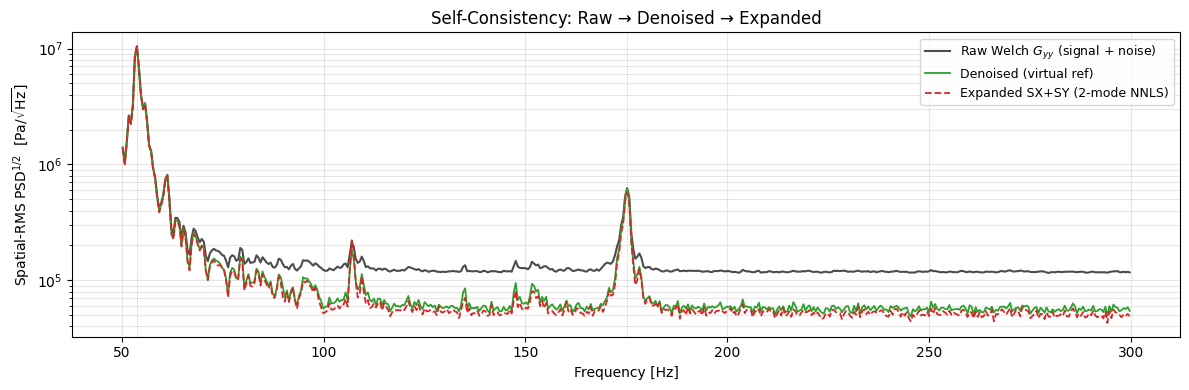

Self-consistency at resonances:
  Mode           Raw Gyy    Denoised    Expanded   Den/Raw   Exp/Den
  53.7 Hz     1.05e+07    1.05e+07    1.03e+07     1.000     0.986
  175.2 Hz     6.24e+05    6.11e+05    5.69e+05     0.979     0.932

  Interpretation:
  - Den/Raw < 1.0  →  noise removed by virtual reference
  - Exp/Den ≈ 1.0  →  modal truncation costs little at resonances
  - The expanded result now represents NOISE-FREE structural PSD

MAC at resonances (squared mode shape vs denoised PSD pattern):
  Mode 1 (53.7 Hz):  MAC = 0.9882
  Mode 2 (175.2 Hz):  MAC = 0.9244

Reconstruction accuracy at resonances:
  Mode 1 (53.7 Hz):  accuracy = 89.2%
  Mode 2 (175.2 Hz):  accuracy = 72.5%

Integrated power per mode (spatial-RMS):
  Mode 1 (53.7 Hz):  integral(beta) = 1.7366e+17 Pa^2
  Mode 2 (175.2 Hz):  integral(beta) = 1.6581e+15 Pa^2


In [72]:
# ---- 1. Self-consistency: three-level comparison ----
rms_raw_val      = np.sqrt(np.mean(S_cam_nodes, axis=1))
rms_denoised_val = np.sqrt(np.mean(S_denoised_nodes, axis=1))
rms_expanded_val = np.sqrt(np.mean(S_stress['SX+SY'], axis=1))

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(f_b, rms_raw_val,      'k',    lw=1.5, label='Raw Welch $G_{yy}$ (signal + noise)', alpha=0.7)
ax.semilogy(f_b, rms_denoised_val,  'C2-',  lw=1.3, label='Denoised (virtual ref)')
ax.semilogy(f_b, rms_expanded_val,  'C3--', lw=1.3, label=f'Expanded SX+SY ({n_modes}-mode NNLS)')
for fp in f_peaks:
    ax.axvline(fp, color='grey', ls=':', lw=0.7, alpha=0.5)
ax.set_xlabel('Frequency [Hz]')
ax.set_ylabel('Spatial-RMS PSD$^{1/2}$  [Pa/$\\sqrt{\\mathrm{Hz}}$]')
ax.set_title('Self-Consistency: Raw → Denoised → Expanded')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, which='both')
plt.tight_layout()
plt.show()

# ---- Quantitative breakdown ----
print('Self-consistency at resonances:')
print(f'  {"Mode":<10s}  {"Raw Gyy":>10s}  {"Denoised":>10s}  {"Expanded":>10s}'
      f'  {"Den/Raw":>8s}  {"Exp/Den":>8s}')
for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    r_raw = rms_raw_val[k_res]
    r_den = rms_denoised_val[k_res]
    r_exp = rms_expanded_val[k_res]
    print(f'  {f_peaks[m]:.1f} Hz   {r_raw:10.2e}  {r_den:10.2e}  {r_exp:10.2e}'
          f'  {r_den/(r_raw+1e-30):8.3f}  {r_exp/(r_den+1e-30):8.3f}')

print()
print('  Interpretation:')
print('  - Den/Raw < 1.0  →  noise removed by virtual reference')
print('  - Exp/Den ≈ 1.0  →  modal truncation costs little at resonances')
print('  - The expanded result now represents NOISE-FREE structural PSD')

# ---- 2. MAC at resonances ----
print('\nMAC at resonances (squared mode shape vs denoised PSD pattern):')
for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    phi_m = Phi_cam[:, m]
    s_m   = S_denoised_nodes[k_res]
    s_m_n = s_m / (np.linalg.norm(s_m) + 1e-30)
    phi_n = phi_m / (np.linalg.norm(phi_m) + 1e-30)
    mac   = np.abs(phi_n @ s_m_n) ** 2
    print(f'  Mode {m+1} ({f_peaks[m]:.1f} Hz):  MAC = {mac:.4f}')

# ---- 3. Reconstruction accuracy at resonances ----
print('\nReconstruction accuracy at resonances:')
for m in range(n_modes):
    k_res = np.argmin(np.abs(f_b - f_peaks[m]))
    print(f'  Mode {m+1} ({f_peaks[m]:.1f} Hz):  accuracy = {accuracy[k_res]:.1f}%')

# ---- 4. Dominance: integrated power per mode ----
df_b = float(np.median(np.diff(f_b)))
print('\nIntegrated power per mode (spatial-RMS):')
for m in range(n_modes):
    power_m = np.sum(beta[:, m]) * df_b
    print(f'  Mode {m+1} ({f_peaks[m]:.1f} Hz):  integral(beta) = {power_m:.4e} Pa^2')

---
## Summary

### Outputs produced
- `S_stress[comp]` &mdash; **noise-free** stress PSD for SX, SY, SXY, SX+SY at every FE node, shape `(n_freq, n_nodes)`, units Pa$^2$/Hz
- `beta` &mdash; modal participation PSD, shape `(n_freq, n_modes)`, real $\ge 0$
- `S_denoised_nodes` &mdash; virtual-reference-denoised camera PSD (intermediate, used as NNLS input)

### Key advantage
No accelerometer required. The camera time history contains the full stress
response. Virtual reference denoising leverages the spatial redundancy of the
camera (930 pixels) to remove measurement noise, then the NNLS decomposition
extracts modal contributions and Stage 1 mode shapes provide the relationship
between stress components.

### Limitations
- **Cannot separate structure from excitation.** If the excitation profile
  changes, the camera measurement must be repeated. (The transmissibility
  method avoids this by isolating the structural transfer function $T(f,x)$.)
- **Virtual reference quality depends on mode shape spatial average.** If a
  mode shape has near-zero spatial mean (highly antisymmetric), the virtual
  reference will not capture it well. For our plate modes this is not an issue.

### Comparison: both methods produce noise-free results

| Aspect | Direct PSD + virtual ref (this notebook) | Transmissibility (companion) |
|--------|----------------------------------------|------------------------------|
| **Input data** | Denoised camera PSD via $|G_{xr}|^2/G_{rr}$ | H1 transmissibility $G_{\sigma a}/G_{aa}$ |
| **Reference signal** | Virtual (averaged camera pixels) | Physical (accelerometer) |
| **Noise removal** | Via inter-pixel cross-spectra | Via camera-accel cross-spectrum |
| **Result** | Noise-free structural PSD | Noise-free structural PSD |
| **Accelerometer** | Not needed | Required |
| **Excitation-dependent** | Yes (PSD baked in) | No (T is structural property) |
| **Extra hardware** | Camera only | Camera + accelerometer |

Both methods produce noise-free structural stress PSDs. The transmissibility
method additionally separates the structural transfer function from the excitation,
making it reusable. The direct PSD method is simpler (no accelerometer) and
demonstrates that spatial redundancy from a full-field camera can replace a
dedicated reference sensor for denoising.

### Quality metrics
- Low NNLS residual confirms the mode shape basis captures the denoised PSD pattern
- MAC near 1.0 at resonances confirms spatial pattern consistency
- Self-consistency: expanded &asymp; denoised (both noise-free)
- Raw Welch > denoised by factor $1/\gamma^2_{vref}$ (noise successfully removed)
- PSD weighting visualization shows how antinodes are prioritised at each resonance

In [73]:
# ==============================================================================
#  SAVE ALL COMPUTED RESULTS FOR ARTICLE FIGURES
# ==============================================================================
import os

SAVE_DIR = Path(r'C:\Users\jasas\Work\Clanki\Clanek_2\thermoelastic-stress-expansion\dual_stage_base_pipeline\outputs\article_data')
os.makedirs(SAVE_DIR, exist_ok=True)

saved_files = []

# 1. Mode shapes for all 4 stress components (normalised, 2 modes)
#    mode_shapes is a dict: {'SX': (n_nodes, n_modes), 'SY': ..., 'SXY': ..., 'SX+SY': ...}
for label, shapes in mode_shapes.items():
    fname = f'dpsd_mode_shapes_{label.replace("+", "plus")}.npy'
    np.save(SAVE_DIR / fname, shapes)
    saved_files.append(fname)

# 2. Modal parameters — natural frequencies and Stage 1 seeds
np.save(SAVE_DIR / 'dpsd_f_peaks.npy', f_peaks)
np.save(SAVE_DIR / 'dpsd_f_peaks_s1.npy', f_peaks_s1)
saved_files += ['dpsd_f_peaks.npy', 'dpsd_f_peaks_s1.npy']

# 3. Raw camera Welch PSD mapped to nodes
np.save(SAVE_DIR / 'dpsd_S_cam_nodes.npy', S_cam_nodes)
saved_files.append('dpsd_S_cam_nodes.npy')

# 4. Virtual-reference denoised PSD mapped to nodes
np.save(SAVE_DIR / 'dpsd_S_denoised_nodes.npy', S_denoised_nodes)
saved_files.append('dpsd_S_denoised_nodes.npy')

# 5. Virtual-reference coherence field
np.save(SAVE_DIR / 'dpsd_coh_vref_nodes.npy', coh_vref_nodes)
saved_files.append('dpsd_coh_vref_nodes.npy')

# 6. NNLS coefficients beta(f) — modal participation PSD
np.save(SAVE_DIR / 'dpsd_beta.npy', beta)
saved_files.append('dpsd_beta.npy')

# 7. NNLS reconstruction of camera-component PSD
np.save(SAVE_DIR / 'dpsd_S_recon.npy', S_recon)
saved_files.append('dpsd_S_recon.npy')

# 8. Expanded stress PSD for each component
for label, S in S_stress.items():
    fname = f'dpsd_S_stress_{label.replace("+", "plus")}.npy'
    np.save(SAVE_DIR / fname, S)
    saved_files.append(fname)

# 9. Squared mode shape basis (Phi = |psi|^2)
for label, phi in Phi.items():
    fname = f'dpsd_Phi_{label.replace("+", "plus")}.npy'
    np.save(SAVE_DIR / fname, phi)
    saved_files.append(fname)

# 10. Frequency axis (Stage 2 band-limited)
np.save(SAVE_DIR / 'dpsd_f_b.npy', f_b)
saved_files.append('dpsd_f_b.npy')

# 11. Stage 1 frequency axis
np.save(SAVE_DIR / 'dpsd_freq_axis_s1.npy', freq_axis)
saved_files.append('dpsd_freq_axis_s1.npy')

# 12. Node coordinates
np.save(SAVE_DIR / 'dpsd_node_coords.npy', node_coords)
saved_files.append('dpsd_node_coords.npy')

# 13. Denoising and reconstruction quality metrics
np.save(SAVE_DIR / 'dpsd_nnls_residual.npy', nnls_residual)
np.save(SAVE_DIR / 'dpsd_accuracy.npy', accuracy)
saved_files += ['dpsd_nnls_residual.npy', 'dpsd_accuracy.npy']

# 14. Metadata (JSON)
metadata = {
    'n_nodes': int(n_nodes),
    'n_modes': int(n_modes),
    'n_freq_b': int(len(f_b)),
    'n_freq_s1': int(n_freq_s1),
    'f_peaks_hz': f_peaks.tolist(),
    'f_peaks_s1_hz': f_peaks_s1.tolist(),
    'f_min': float(F_MIN),
    'f_max': float(F_MAX),
    'fs_ir': float(FS_IR),
    'seg_len': int(seg_len),
    'n_segments': int(N_SEGMENTS),
    'comp_labels': list(COMPS.values()),
    'rows_grid': int(rows_grid),
    'cols_grid': int(cols_grid),
    'stage1_run': STAGE1_RUN,
    'method': 'direct_psd_expansion',
}
with open(SAVE_DIR / 'dpsd_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
saved_files.append('dpsd_metadata.json')

# ---- Summary ----
print(f'Saved {len(saved_files)} files to {SAVE_DIR}')
print()
for fname in saved_files:
    fpath = SAVE_DIR / fname
    size_kb = fpath.stat().st_size / 1024
    print(f'  {fname:50s}  {size_kb:8.1f} KB')

Saved 25 files to C:\Users\jasas\Work\Clanki\Clanek_2\thermoelastic-stress-expansion\dual_stage_base_pipeline\outputs\article_data

  dpsd_mode_shapes_SX.npy                                 18.2 KB
  dpsd_mode_shapes_SY.npy                                 18.2 KB
  dpsd_mode_shapes_SXY.npy                                18.2 KB
  dpsd_mode_shapes_SXplusSY.npy                           18.2 KB
  dpsd_f_peaks.npy                                         0.1 KB
  dpsd_f_peaks_s1.npy                                      0.1 KB
  dpsd_S_cam_nodes.npy                                  4497.7 KB
  dpsd_S_denoised_nodes.npy                             4497.7 KB
  dpsd_coh_vref_nodes.npy                               4497.7 KB
  dpsd_beta.npy                                            7.9 KB
  dpsd_S_recon.npy                                      4497.7 KB
  dpsd_S_stress_SX.npy                                  4497.7 KB
  dpsd_S_stress_SY.npy                                  4497.7 KB
  dpsd_S_s